In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
ftsz = 12
plt.rcParams["font.family"] = "Serif"
plt.rc('xtick', labelsize=ftsz)
plt.rc('ytick', labelsize=ftsz)

# Au-Ag sysem: solid solution and atom swaps

Run at 900 C, pure NVT. The system is initialised with two blocks of Ag and Au in contact, with a vacancy concentration of 1% to aid solid solution. The two slowly start mixing.


In [12]:
data_NVTonly = np.loadtxt('AgAu_nvt_900C_1pcv.dat', skiprows=1)
data_NVT_atomswap = np.loadtxt('AgAu_nvt_900C_atomswap_1pcv.dat', skiprows=1)

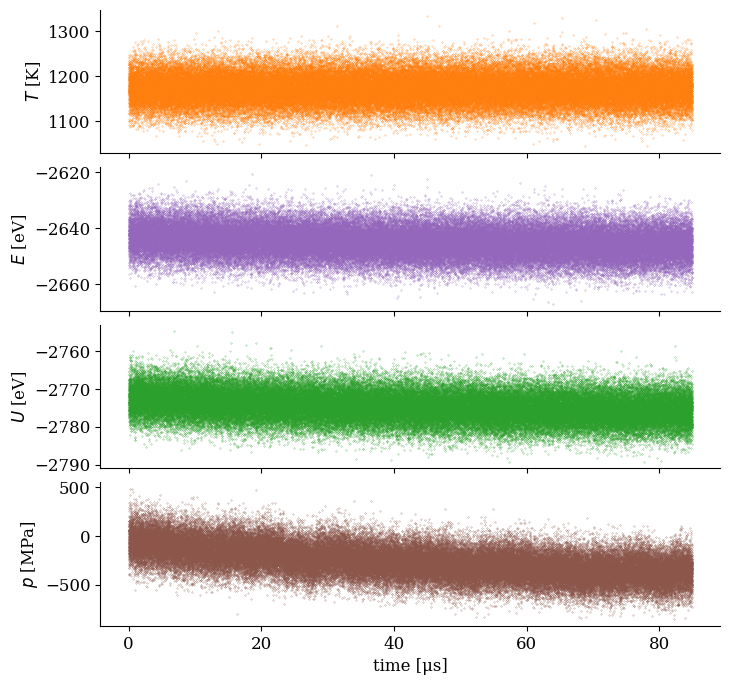

In [11]:
# Check the time evolution

fig, ax = plt.subplots(4, 1, figsize=(8, 8), sharex=True, gridspec_kw={"hspace": 0.1})

# Each entry: (column index in data, scale_factor, ylabel)
channels = [
    (1, 1,          r"$T$ [K]"),
    (4, 1,  r"$E$ [eV]"),
    (2, 1,  r"$U$ [eV]"),
    (5, 0.1,   r"$p$ [MPa]"),
]

t = (data_NVTonly[:, 0] - data_NVTonly[0, 0])*1e-6 # ps to us
for axis, (col, scale, label) in zip(ax, channels):
    axis.plot(t, scale * data_NVTonly[:, col], 'o', markersize=0.2, color=f'C{col}')
    
for axis, (_, _, label) in zip(ax, channels):
    axis.set_ylabel(label, fontsize=ftsz)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
ax[3].set_xlabel("time [μs]", fontsize=ftsz)

plt.show()

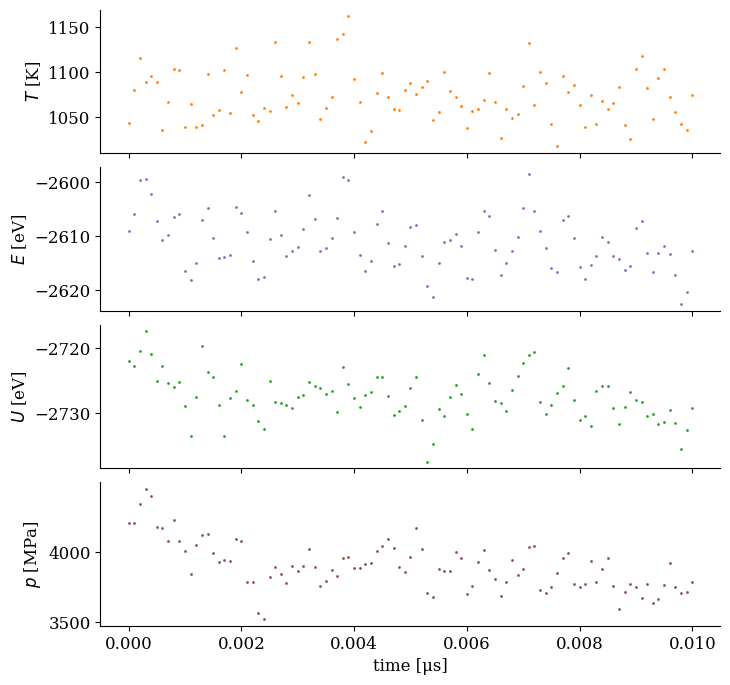

In [15]:
# Check the time evolution

fig, ax = plt.subplots(4, 1, figsize=(8, 8), sharex=True, gridspec_kw={"hspace": 0.1})

# Each entry: (column index in data, scale_factor, ylabel)
channels = [
    (1, 1,          r"$T$ [K]"),
    (4, 1,  r"$E$ [eV]"),
    (2, 1,  r"$U$ [eV]"),
    (5, 0.1,   r"$p$ [MPa]"),
]

t = (data_NVT_atomswap[:, 0] - data_NVT_atomswap[0, 0])*1e-6 # ps to us
for axis, (col, scale, label) in zip(ax, channels):
    axis.plot(t, scale * data_NVT_atomswap[:, col], 'o', markersize=1., color=f'C{col}')
    
for axis, (_, _, label) in zip(ax, channels):
    axis.set_ylabel(label, fontsize=ftsz)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
ax[3].set_xlabel("time [μs]", fontsize=ftsz)

plt.show()

## Coordination analysis

Let's check with Ovito. We expect the cross-correlation to rise in both cases. But how fast with increasing timestep?